In [4]:
# =============================================================================
# BLOCK 1: SIMULATION LIBRARIES AND GLOBAL CONFIGURATION
# =============================================================================

import math
import random
import heapq
import statistics
from dataclasses import dataclass, field
from collections import defaultdict, deque
from pathlib import Path
from zipfile import ZipFile
import xml.etree.ElementTree as ET

# Data analysis and scientific computing
try:
    import pandas as pd
except ImportError:
    pd = None

try:
    import numpy as np
except ImportError:
    np = None

try:
    import scipy.stats as stats
except ImportError:
    stats = None

# Visualization libraries
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
except ImportError:
    plt = None
    sns = None

# Global File Path
DATA_FILE = Path("samples_for_simulation.xlsx")

# Simulation Time Constants (in minutes)
# Day 1: 09:00 (Minute 0.0) to 20:00 (Minute 660.0)
# Day 2: 09:00 (Minute 1440.0) to 20:00 (Minute 2100.0)
DAY_STARTS = [0.0, 1440.0]
DAY_ENDS = [660.0, 2100.0]
SIM_END = 2100.0
EPS = 1e-12       # Epsilon to prevent division by zero


# Statistics Tests for known data distribution


In [5]:
def read_xlsx_first_column(path: Path, sheet_name: str) -> list:
  # Reads empirical data from the first column of a given Excel sheet.

    if not path.exists():
        raise FileNotFoundError(
            f"Required file '{path.name}' not found. Please upload it to your Colab runtime."
        )

    if pd is not None:
        df = pd.read_excel(path, sheet_name=sheet_name)
        return [float(x) for x in df.iloc[:, 0].dropna().tolist()]

    # Fallback XML parsing mechanism
    ns = {
        "a": "http://schemas.openxmlformats.org/spreadsheetml/2006/main",
        "r": "http://schemas.openxmlformats.org/officeDocument/2006/relationships",
    }
    with ZipFile(path) as zf:
        shared = []
        if "xl/sharedStrings.xml" in zf.namelist():
            root = ET.fromstring(zf.read("xl/sharedStrings.xml"))
            for si in root.findall("a:si", ns):
                shared.append("".join(t.text or "" for t in si.findall(".//a:t", ns)))

        workbook = ET.fromstring(zf.read("xl/workbook.xml"))
        rels = ET.fromstring(zf.read("xl/_rels/workbook.xml.rels"))
        relmap = {rel.attrib["Id"]: rel.attrib["Target"] for rel in rels}

        sheet_path = None
        for sheet in workbook.findall("a:sheets/a:sheet", ns):
            if sheet.attrib["name"] == sheet_name:
                rid = sheet.attrib["{http://schemas.openxmlformats.org/officeDocument/2006/relationships}id"]
                sheet_path = "xl/" + relmap[rid].lstrip("/")
                break

        if sheet_path is None:
            raise ValueError(f"Sheet name not found: {sheet_name}")

        root = ET.fromstring(zf.read(sheet_path))
        values = []
        for row in root.findall("a:sheetData/a:row", ns)[1:]:
            cell = row.find("a:c", ns)
            if cell is None: continue
            value = cell.find("a:v", ns)
            if value is None: continue
            raw = value.text
            if cell.attrib.get("t") == "s":
                raw = shared[int(raw)]
            values.append(float(raw))
        return values


def load_and_plot_data():
    """
    Loads the empirical datasets.
    """
    # Load raw data from Excel sheets
    datasets = {
        "FriendsGroup Interarrival": read_xlsx_first_column(DATA_FILE, "FriendsGroup_arrival_intervals"),
        "MainStage Duration": read_xlsx_first_column(DATA_FILE, "MainStage_concert_duration")
    }
    return datasets

# Execute code to extract data
historical_data = load_and_plot_data()

ANALYSIS REPORT FOR: FriendsGroup Interarrival
Exponential Distribution:
  Estimated Rate (lambda): 0.72927
  Log-Likelihood: -131.57
  KS Test Statistic: 0.0885 | p-value: 0.39138
----------------------------------------
Normal Distribution:
  Estimated Mean (mu): 1.3712
  Estimated StdDev (sigma): 1.1878
  Log-Likelihood: -159.10
  KS Test Statistic: 0.2025 | p-value: 0.00045


ANALYSIS REPORT FOR: MainStage Duration
Exponential Distribution:
  Estimated Rate (lambda): 0.02179
  Log-Likelihood: -482.65
  KS Test Statistic: 0.4198 | p-value: 0.00000
----------------------------------------
Normal Distribution:
  Estimated Mean (mu): 45.9028
  Estimated StdDev (sigma): 8.9274
  Log-Likelihood: -360.81
  KS Test Statistic: 0.1024 | p-value: 0.22900




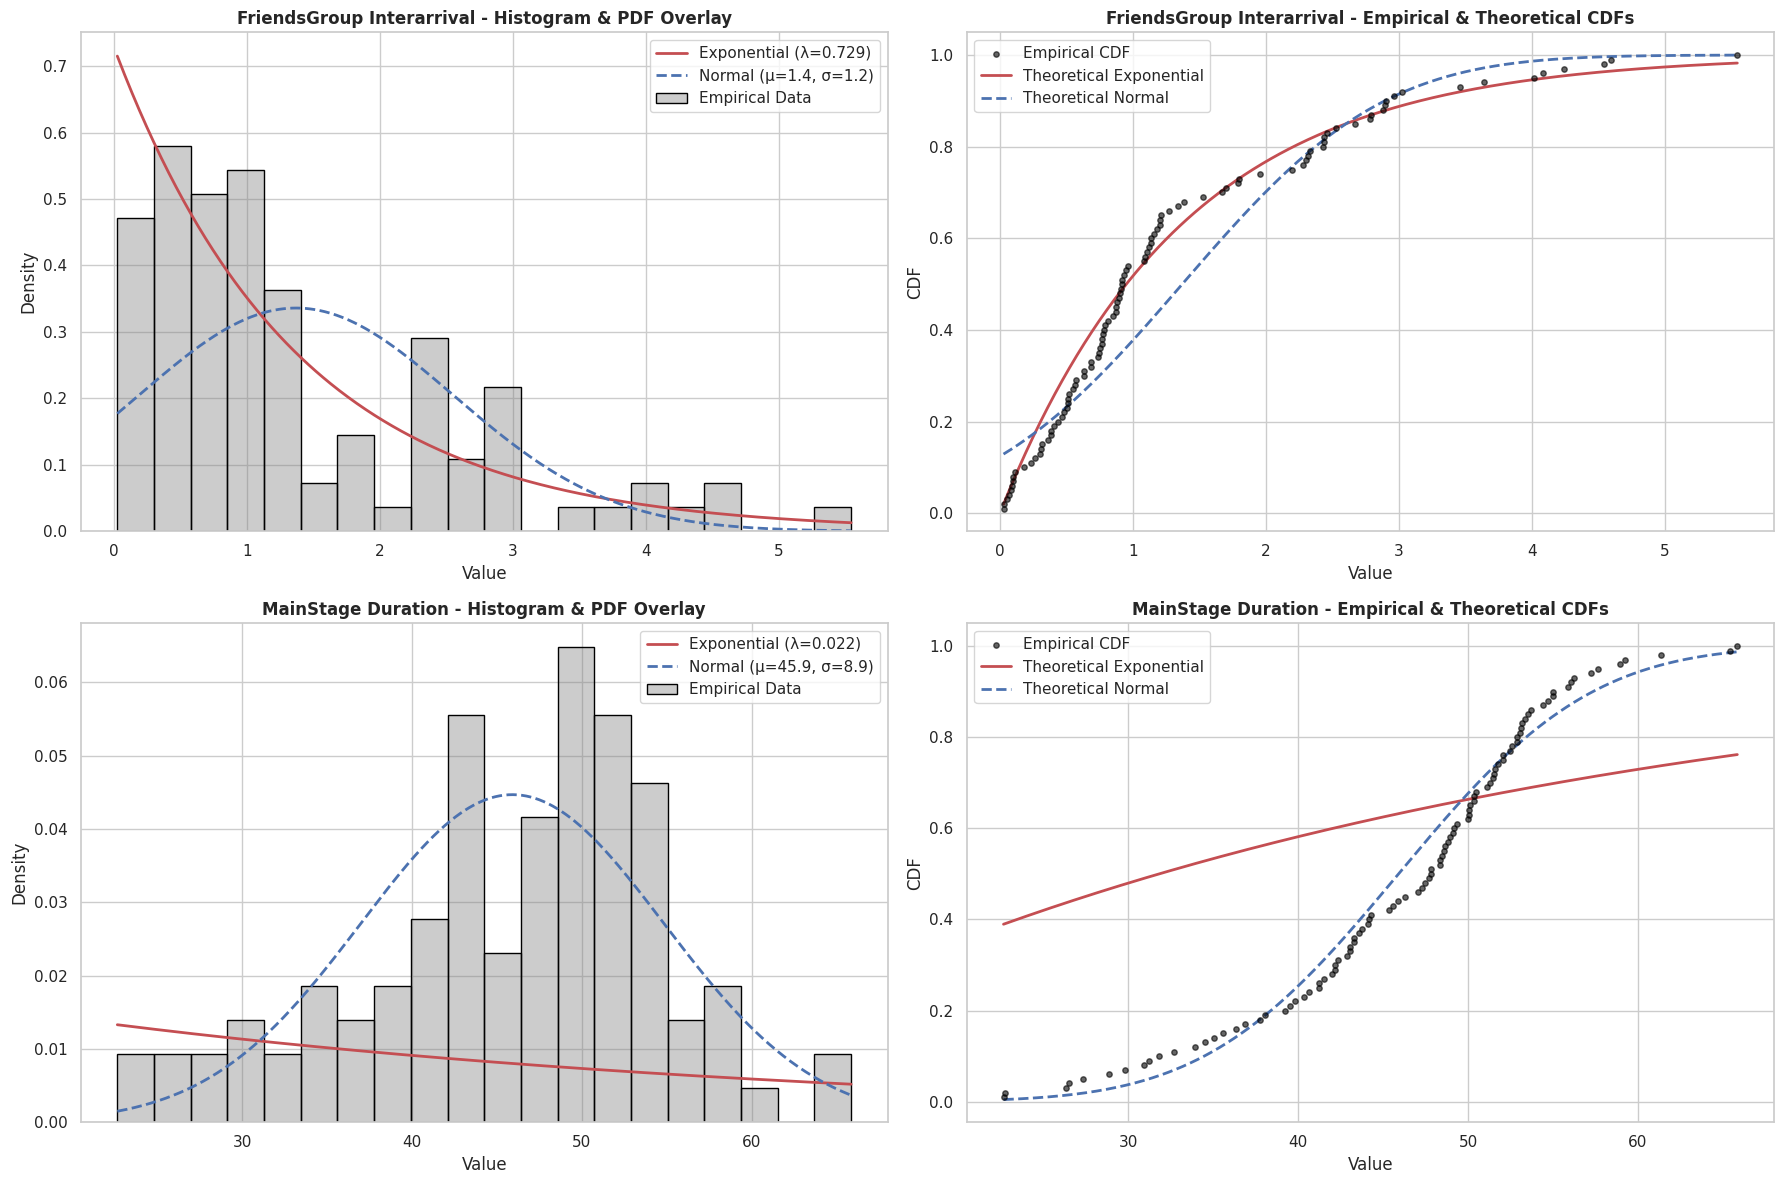

In [6]:
import numpy as np
try:
    import scipy.stats as stats
except ImportError:
    stats = None

def fit_and_test_distributions(datasets: dict):
    """
    Fits Exponential and Normal distributions to the empirical data.
    Calculates Log-Likelihood, and conducts a Kolmogorov-Smirnov test.
    Plots both PDF and CDF overlays for complete academic validation.
    """
    if plt is None or sns is None or stats is None:
        print("Required scientific/plotting libraries are missing. Cannot run analysis.")
        return

    sns.set_theme(style="whitegrid")

    # Create a single figure with 2 rows and 2 columns for all plots
    fig, axes = plt.subplots(len(datasets), 2, figsize=(18, 6 * len(datasets))) # Adjust figsize as needed
    # Flatten axes if there's only one row for easier indexing
    if len(datasets) == 1:
        axes = np.expand_dims(axes, axis=0)

    plot_row_idx = 0 # To keep track of which row we are plotting to

    for name, data in datasets.items():
        data_arr = np.array(data)
        n = len(data_arr)

        # --- 1. Statistical Fitting ---
        # Fit Exponential: returns (loc, scale) where lambda = 1/scale. We fix loc=0 for standard expo.
        exp_loc, exp_scale = stats.expon.fit(data_arr, floc=0)
        exp_lambda = 1.0 / exp_scale

        # Fit Normal: returns (mu, sigma)
        norm_mu, norm_sigma = stats.norm.fit(data_arr)

        # --- 2. Calculate Fitness Metrics (Log-Likelihood) ---
        # Exponential metrics
        exp_log_lik = np.sum(stats.expon.logpdf(data_arr, loc=exp_loc, scale=exp_scale))

        # Normal metrics
        norm_log_lik = np.sum(stats.norm.logpdf(data_arr, loc=norm_mu, scale=norm_sigma))

        # --- 3. Hypothesis Testing (Kolmogorov-Smirnov Test) ---
        exp_ks_stat, exp_ks_p = stats.kstest(data_arr, 'expon', args=(exp_loc, exp_scale))
        norm_ks_stat, norm_ks_p = stats.kstest(data_arr, 'norm', args=(norm_mu, norm_sigma))

        # --- 4. Print Text Analysis (To be used for your report text) ---
        print("=" * 60)
        print(f"ANALYSIS REPORT FOR: {name}")
        print("=" * 60)
        print(f"Exponential Distribution:")
        print(f"  Estimated Rate (lambda): {exp_lambda:.5f}")
        print(f"  Log-Likelihood: {exp_log_lik:.2f}")
        print(f"  KS Test Statistic: {exp_ks_stat:.4f} | p-value: {exp_ks_p:.5f}")
        print("-" * 40)
        print(f"Normal Distribution:")
        print(f"  Estimated Mean (mu): {norm_mu:.4f}")
        print(f"  Estimated StdDev (sigma): {norm_sigma:.4f}")
        print(f"  Log-Likelihood: {norm_log_lik:.2f}")
        print(f"  KS Test Statistic: {norm_ks_stat:.4f} | p-value: {norm_ks_p:.5f}")
        print("\n")

        # --- 5. Generate Dual Academic Plots (PDF and CDF) ---
        x_eval = np.linspace(min(data_arr), max(data_arr), 500)

        # Plot A: Histogram and Theoretical Densities (PDF)
        sns.histplot(data_arr, stat="density", bins=20, alpha=0.4, color="gray", edgecolor="black", label="Empirical Data", ax=axes[plot_row_idx, 0])
        axes[plot_row_idx, 0].plot(x_eval, stats.expon.pdf(x_eval, loc=exp_loc, scale=exp_scale), 'r-', lw=2, label=f"Exponential (λ={exp_lambda:.3f})")
        axes[plot_row_idx, 0].plot(x_eval, stats.norm.pdf(x_eval, loc=norm_mu, scale=norm_sigma), 'b--', lw=2, label=f"Normal (μ={norm_mu:.1f}, σ={norm_sigma:.1f})")
        axes[plot_row_idx, 0].set_title(f"{name} - Histogram & PDF Overlay", fontsize=12, fontweight='bold')
        axes[plot_row_idx, 0].set_xlabel("Value")
        axes[plot_row_idx, 0].set_ylabel("Density")
        axes[plot_row_idx, 0].legend()

        # Plot B: Empirical and Theoretical CDFs
        # Sort data for empirical CDF plotting
        x_sorted = np.sort(data_arr)
        y_ecdf = np.arange(1, n + 1) / n
        axes[plot_row_idx, 1].scatter(x_sorted, y_ecdf, color="black", s=15, alpha=0.6, label="Empirical CDF", zorder=3)
        axes[plot_row_idx, 1].plot(x_eval, stats.expon.cdf(x_eval, loc=exp_loc, scale=exp_scale), 'r-', lw=2, label="Theoretical Exponential")
        axes[plot_row_idx, 1].plot(x_eval, stats.norm.cdf(x_eval, loc=norm_mu, scale=norm_sigma), 'b--', lw=2, label="Theoretical Normal")
        axes[plot_row_idx, 1].set_title(f"{name} - Empirical & Theoretical CDFs", fontsize=12, fontweight='bold')
        axes[plot_row_idx, 1].set_xlabel("Value")
        axes[plot_row_idx, 1].set_ylabel("CDF")
        axes[plot_row_idx, 1].legend()

        plot_row_idx += 1

    plt.tight_layout()
    plt.show()

# Run the complete analysis on the historical data
fit_and_test_distributions(historical_data)

### מדדי טיב התאמה

לאחר התאמת התפלגויות תיאורטיות לנתונים אמפיריים, אנו משתמשים במדדים סטטיסטיים להערכת טיב ההתאמה.

#### 1. Log-Likelihood (לוג-סבירות)

*   **מה זה:** מדד לכמה סביר שהמודל יצר את הנתונים הנצפים. ככל שה-Log-Likelihood גבוה יותר, כך ההתאמה טובה יותר.

#### 2. מבחן קולמוגורוב-סמירנוב (Kolmogorov-Smirnov Test - KS Test)

*   **מה זה:** מבחן השערות הבודק אם הנתונים האמפיריים מגיעים מההתפלגות התיאורטית שאותה התאמנו.
*   **ערך p (p-value):**
    *   **ערך p גבוה (לרוב > 0.05):** אין מספיק ראיות לדחות את השערת האפס; התאמה טובה.
    *   **ערך p נמוך (לרוב < 0.05):** דחיית השערת האפס; התאמה פחות טובה.

### מסקנות מתוצאות התאמת ההתפלגויות

על בסיס המדדים הסטטיסטיים (Log-Likelihood) ומבחן קולמוגורוב-סמירנוב (KS Test), אנו יכולים להסיק לגבי ההתפלגויות המתאימות ביותר לכל אחד ממערכי הנתונים:

#### 1. זמני הגעה בין קבוצות חברים (FriendsGroup Interarrival Times)

*   **התפלגות אקספוננציאלית (Exponential Distribution):** הציגה ערכי Log-Likelihood גבוהים יותר בהשוואה להתפלגות הנורמלית. בנוסף, ערך ה-p של מבחן KS (0.39138) גבוה משמעותית מ-0.05, מה שמעיד על התאמה טובה לנתונים.
*   **התפלגות נורמלית (Normal Distribution):** הציגה ערכי Log-Likelihood נמוכים יותר. ערך ה-p של מבחן KS (0.00045) נמוך מ-0.05, מה שמוביל לדחיית ההשערה שהנתונים מגיעים מהתפלגות נורמלית.
*   **מסקנה:** הנתונים של **זמני ההגעה בין קבוצות חברים מתאימים טוב יותר להתפלגות אקספוננציאלית**.

#### 2. משכי קונצרטים בבמה המרכזית (MainStage Concert Durations)

*   **התפלגות אקספוננציאלית (Exponential Distribution):** הציגה ערכי Log-Likelihood נמוכים יותר בהשוואה להתפלגות הנורמלית. ערך ה-p של מבחן KS (0.00000) נמוך מ-0.05, מה שמוביל לדחיית ההשערה שהנתונים מגיעים מהתפלגות אקספוננציאלית.
*   **התפלגות נורמלית (Normal Distribution):** הציגה ערכי Log-Likelihood גבוהים יותר. ערך ה-p של מבחן KS (0.22900) גבוה מ-0.05, מה שמעיד על התאמה טובה לנתונים.
*   **מסקנה:** הנתונים של **משכי קונצרטים בבמה המרכזית מתאימים טוב יותר להתפלגות נורמלית**.


### אישוש התפלגות באמצעות מבחן Kolmogorov-Smirnov (KS)

בהתבסס על תוצאות מבחן KS, נבדקה התאמה של 'זמני הגעה בין קבוצות חברים' ו'משך קונצרט בבמה המרכזית' להתפלגות אקספוננציאלית.

#### תוצאות עבור 'זמני הגעה בין קבוצות חברים':
סטטיסטיקת D:
D=0.0885

ערך p:
p=0.39138

מכיוון ש־ p > 0.10 (בהנחה רמת מובהקות של 10%), אין לנו מספיק עדות לדחות את השערת האפס, ולכן ניתן לומר שהנתונים מתאימים להתפלגות אקספוננציאלית עם הפרמטר שחושב.

#### תוצאות עבור 'משך קונצרט בבמה המרכזית':
סטטיסטיקת D:
D=0.4198

ערך p:
p=0.00000

מכיוון ש־ p < 0.10 (בהנחה רמת מובהקות של 10%), אנו דוחים את השערת האפס, ולכן הנתונים **אינם** מתאימים להתפלגות אקספוננציאלית.

#### מסקנה:
בהתאם לממצאים, ניתן לומר כי:

*   'זמן הגעה בין קבוצות חברים' מתפלג אקספוננציאלית עם הפרמטר
    λ=0.72927

*   'משך קונצרט בבמה המרכזית' **אינו** מתפלג אקספוננציאלית. ההתאמה הטובה ביותר עבור נתונים אלו, כפי שמוצג בתא `5e9537ed`, היא להתפלגות נורמלית.

## Sampling Algorithms

In [7]:
# Sampler Class
class Sampler:

    # Queue to store the second value from Box-Muller, if generated
    _box_muller_extra = deque()

    # u
    @staticmethod
    def u():
        eps_val = 1e-12
        return min(max(random.random(), eps_val), 1.0 - eps_val)

    # uniform
    @staticmethod
    def uniform(a, b):
        return a + (b - a) * Sampler.u()

    # bernoulli
    @staticmethod
    def bernoulli(p):
        return Sampler.u() < p

    # discrete_uniform
    @staticmethod
    def discrete_uniform(a, b):
        return a + int(math.floor((b - a + 1) * Sampler.u()))

    # exponential_inverse
    @staticmethod
    def exponential_inverse(mean):
        return -mean * math.log(1.0 - Sampler.u())

    # discrete_choice_composition
    @staticmethod
    def discrete_choice_composition(weighted_items):
        total = sum(weight for _, weight in weighted_items)
        threshold = Sampler.u() * total
        cumulative = 0.0
        for item, weight in weighted_items:
            cumulative += weight
            if threshold <= cumulative:
                return item
        return weighted_items[-1][0]

    # normal_box_muller
    @staticmethod
    def normal_box_muller(mean, std):
        if Sampler._box_muller_extra:
            return mean + std * Sampler._box_muller_extra.popleft()

        u1 = Sampler.u()
        u2 = Sampler.u()

        # Box-Muller transform
        z0 = math.sqrt(-2.0 * math.log(u1)) * math.cos(2.0 * math.pi * u2)
        z1 = math.sqrt(-2.0 * math.log(u1)) * math.sin(2.0 * math.pi * u2)

        # Store z1 for the next call
        Sampler._box_muller_extra.append(z1)

        # Scale and shift z0
        return mean + std * z0

    # check_in_duration
    @staticmethod
    def check_in_duration():
        return Sampler.uniform(1.5, 3.0)

    # check_out_duration
    @staticmethod
    def check_out_duration():
        return Sampler.exponential_inverse(2.0)

    # sample_friends_interarrival
    @staticmethod
    def sample_friends_interarrival():
        global frieds_group_interarrival_rate
        return Sampler.exponential_inverse(1.0 / frieds_group_interarrival_rate) # mean is 1/lambda

    # couple_interarrival_time
    @staticmethod
    def couple_interarrival_time():
        return Sampler.exponential_inverse(1.0)

    # single_interarrival_time
    @staticmethod
    def single_interarrival_time():
        return Sampler.exponential_inverse(660.0 / 500.0)

    # sample_mainstage_duration
    @staticmethod
    def sample_mainstage_duration():
        global main_stage_duration_mu, main_stage_duration_sigma
        # Ensure duration is not negative
        return max(10.0, Sampler.normal_box_muller(main_stage_duration_mu, main_stage_duration_sigma))

    # destage_duration
    @staticmethod
    def destage_duration():
        return Sampler.uniform(20.0, 30.0)

    # dj_density
    @staticmethod
    def dj_density(x):
        if 20.0 <= x <= 40.0:
            return (x - 30.0) / 600.0
        elif 40.0 < x <= 50.0:
            return (50.0 - x - 20.0) / 6000.0 + (1.0 / 30.0)
        elif 50.0 < x <= 60.0:
            return (60.0 - x) / 600.0
        return 0.0

    # sample_dj_duration_acceptance_rejection
    @staticmethod
    def sample_dj_duration_acceptance_rejection():
        max_density = 1.0 / 15.0
        while True:
            x = Sampler.uniform(20.0, 60.0)
            if Sampler.u() <= Sampler.dj_density(x) / max_density:
                return x

    # photo_density
    @staticmethod
    def photo_density(x):
        if 1.0 <= x < 2.0:
            return x / 6.0
        elif 2.0 <= x < 3.0:
            return x / 5.0 + 1.0 / 8.0
        elif 3.0 <= x < 4.0:
            return 1.0 / 8.0
        return 0.0

    # sample_photo_duration
    @staticmethod
    def sample_photo_duration():
        max_density = 3.0 / 5.0 + 1.0 / 8.0
        while True:
            x = Sampler.uniform(1.0, 4.0)
            if Sampler.u() <= Sampler.photo_density(x) / max_density:
                return x

    # merch_checkout_duration
    @staticmethod
    def merch_checkout_duration():
        return Sampler.uniform(2.0, 6.0)

    # sample_battery
    @staticmethod
    def sample_battery():
        value = Sampler.normal_box_muller(mean=40.0, std=15.0)
        return max(0.0, min(100.0, value))

    # sample_charging_duration
    @staticmethod
    def sample_charging_duration(battery):
        eps_val = 1e-12
        alpha = 100.0 / max(100.0 - battery, eps_val)
        return 40.0 * (1.0 - (Sampler.u() ** (1.0 / alpha)))

    # sample_bodyart_duration
    @staticmethod
    def sample_bodyart_duration(art_type):
        if art_type == "chen":
            return Sampler.normal_box_muller(mean=15.0, std=3.0)
        elif art_type == "neon":
            return Sampler.exponential_inverse(12.0)
        elif art_type == "henna":
            return Sampler.uniform(17.0, 22.0)

    # bar_service_time
    @staticmethod
    def bar_service_time():
        value = Sampler.normal_box_muller(mean=5.0, std=1.5)
        return max(0.1, value)

    # food_prep_duration
    @staticmethod
    def food_prep_duration(restaurant):
        if restaurant == "pizza":
            return Sampler.uniform(4.0, 6.0)
        elif restaurant == "burger":
            return Sampler.uniform(3.0, 4.0)
        elif restaurant == "asian":
            return Sampler.uniform(3.0, 7.0)

    # meal_consumption_duration
    @staticmethod
    def meal_consumption_duration():
        return Sampler.uniform(15.0, 35.0)

   # sample_restaurant_choice
    @staticmethod
    def sample_restaurant_choice():
        return Sampler.discrete_choice_composition([
            ("burger", 3/8),
            ("pizza", 1/4),
            ("asian", 3/8)
        ])

    # sample_bodyart_type
    @staticmethod
    def sample_bodyart_type():
        return Sampler.discrete_choice_composition([
            ("chen", 0.3),
            ("neon", 0.3),
            ("henna", 0.4)
        ])

### 1. משך השירות בעמדת הצילום (PhotoStation)

$$f_{\text{photo}}(x)=\begin{cases}\frac{x}{6},&1\le x<2\\ \frac{x}{5}+\frac{1}{8},&2\le x<3\\ \frac{1}{8},&3\le x<4\end{cases}$$



#### פיתוח פונקציית ההתפלגות המצטברת $F(x)$

* **עבור $1 \le x < 2$:**

$$F(x) = \int_{1}^{x} \frac{t}{6} dt = \left[ \frac{t^2}{12} \right]_{1}^{x} = \frac{x^2 - 1}{12}$$


$$F(2) = \frac{2^2 - 1}{12} = \frac{3}{12} = 0.25$$


* **עבור $2 \le x < 3$:**

$$F(x) = 0.25 + \int_{2}^{x} \left(\frac{t}{5} + \frac{1}{8}\right) dt = 0.25 + \left[ \frac{t^2}{10} + \frac{t}{8} \right]_{2}^{x}$$


$$F(x) = 0.25 + \left(\frac{x^2}{10} + \frac{x}{8}\right) - \left(\frac{4}{10} + \frac{2}{8}\right) = \frac{x^2}{10} + \frac{x}{8} - 0.4$$


$$F(3) = \frac{3^2}{10} + \frac{3}{8} - 0.4 = 0.9 + 0.375 - 0.4 = 0.875$$


* **עבור $3 \le x \le 4$:**

$$F(x) = 0.875 + \int_{3}^{x} \frac{1}{8} dt = 0.875 + \left[ \frac{t}{8} \right]_{3}^{x} = 0.875 + \frac{x}{8} - \frac{3}{8} = \frac{x}{8} + 0.5$$


$$F(4) = \frac{4}{8} + 0.5 = 1.0$$



#### פונקציית ההתפלגות המצטברת $F_{\text{photo}}(x)$

$$F_{\text{photo}}(x)=\begin{cases}\frac{x^2 - 1}{12},&1\le x<2\\ \frac{x^2}{10} + \frac{x}{8} - 0.4,&2\le x<3\\ \frac{x}{8} + 0.5,&3\le x\le 4\end{cases}$$

#### היפוך הפונקציה והשוואה ל-$U \sim U(0,1)$

1. **עבור $0 \le U < 0.25$:**

$$U = \frac{x^2 - 1}{12} \implies 12U = x^2 - 1 \implies x = \sqrt{12U + 1}$$


2. **עבור $0.25 \le U < 0.875$:**

$$U = \frac{x^2}{10} + \frac{x}{8} - 0.4 \implies \frac{1}{10}x^2 + \frac{1}{8}x - (0.4 + U) = 0$$


$$\text{Using quadratic formula: } x = \frac{-b + \sqrt{b^2 - 4ac}}{2a}$$


$$x = \frac{-0.125 + \sqrt{0.015625 + 0.4(0.4 + U)}}{0.2} = \frac{-0.125 + \sqrt{0.4U + 0.175625}}{0.2}$$


3. **עבור $0.875 \le U \le 1$:**

$$U = \frac{x}{8} + 0.5 \implies U - 0.5 = \frac{x}{8} \implies x = 8(U - 0.5)$$



#### פונקציית הדגימה הסופית $F^{-1}_{\text{photo}}(U)$

$$F^{-1}_{\text{photo}}(U)=\begin{cases}\sqrt{12U + 1},&0\le U<0.25\\ \frac{-0.125 + \sqrt{0.4U + 0.175625}}{0.2},&0.25\le U<0.875\\ 8(U - 0.5),&0.875\le U\le 1\end{cases}$$

---

### 2. משך השירות בעמדת טעינת הטלפונים (ChargingStation)

$$f(t) = \frac{\alpha}{40^{\alpha}}(40-t)^{\alpha-1}, \quad 0\le t\le40, \quad \alpha=\frac{100}{100-b}$$



####  פיתוח פונקציית ההתפלגות המצטברת $F(t)$

$$F(t) = \int_{0}^{t} \frac{\alpha}{40^{\alpha}}(40-k)^{\alpha-1} dk$$

$$\text{Let } 40-k = s \implies dk = -ds$$

$$F(t) = \frac{\alpha}{40^{\alpha}} \int_{40}^{40-t} -s^{\alpha-1} ds = \frac{\alpha}{40^{\alpha}} \int_{40-t}^{40} s^{\alpha-1} ds$$

$$F(t) = \frac{\alpha}{40^{\alpha}} \left[ \frac{s^{\alpha}}{\alpha} \right]_{40-t}^{40} = \frac{1}{40^{\alpha}} \left( 40^{\alpha} - (40-t)^{\alpha} \right)$$

$$F(t) = 1 - \left(\frac{40-t}{40}\right)^{\alpha}$$

#### היפוך הפונקציה והשוואה ל-$U \sim U(0,1)$

$$U = 1 - \left(\frac{40-t}{40}\right)^{\alpha}$$

$$1 - U = \left(\frac{40-t}{40}\right)^{\alpha}$$

$$(1 - U)^{1/\alpha} = \frac{40-t}{40}$$

$$40(1 - U)^{1/\alpha} = 40 - t$$

$$t = 40 \left(1 - (1 - U)^{1/\alpha}\right)$$

$$\text{Since } U \sim U(0,1) \implies (1-U) \sim U(0,1)$$

#### פונקציית הדגימה הסופית $F^{-1}_{\text{charge}}(U)$

$$F^{-1}_{\text{charge}}(U) = 40 \left(1 - U^{1/\alpha}\right)$$

### 3. דגימה בשיטת קבלה-דחייה: משך סט די-ג'יי (DJ Duration)

פונקציית הצפיפות $f(x)$ עבור משך הנגינה של הדי-ג'יי מוגדרת כדלקמן (על פי הקוד):

$$f(x) = \begin{cases} \frac{x - 30}{600}, & 20 \le x \le 40 \\ \frac{50 - x - 20}{6000} + \frac{1}{30}, & 40 < x \le 50 \\ \frac{60 - x}{600}, & 50 < x \le 60 \end{cases}$$

#### שלבי האלגוריתם:

1. **בחירת פונקציית עזר $g(x)$ וקבוע $M$:**
   בשיטה זו אנו בוחרים התפלגות שקל לדגום ממנה, לרוב התפלגות אחידה $U(a, b)$. כאן נבחר $g(x) \sim U(20, 60)$.
   צפיפות ההתפלגות האחידה היא $g(x) = \frac{1}{60-20} = \frac{1}{40}$.
   עלינו למצוא קבוע $M$ כך שמתקיים $f(x) \le M \cdot g(x)$ לכל $x$. הערך המקסימלי של $f(x)$ הוא $1/15$ (בנקודה $x=40$).
   לכן: $M = \frac{\max(f(x))}{g(x)} = \frac{1/15}{1/40} = \frac{40}{15} = \frac{8}{3}$.

2. **תהליך הדגימה:**
   *   דוגמים $X$ מתוך $g(x)$ (כלומר, $X = 20 + 40 \cdot U_1$).
   *   דוגמים מספר אקראי נוסף $U_2 \sim U(0, 1)$.
   *   **תנאי הקבלה:** אם $U_2 \le \frac{f(X)}{M \cdot g(X)}$, נקבל את $X$.
   במקרה שלנו, כיוון ש-$M \cdot g(X) = \max(f(x)) = 1/15$, התנאי הופך ל:
   $$U_2 \le \frac{f(X)}{1/15} \implies U_2 \le 15 \cdot f(X)$$

#### חישוב ידני לדוגמה:
נניח שדגמנו $U_1 = 0.25$, לכן $X = 20 + 40 \cdot 0.25 = 30$.
נחשב את ערך הצפיפות בנקודה זו: $f(30) = \frac{30-30}{600} = 0$.
התנאי יהיה $U_2 \le 15 \cdot 0 = 0$. מכיוון ש-$U_2$ תמיד חיובי, הערך יידחה ונדגום שוב.

נניח שדגמנו $U_1 = 0.5$, לכן $X = 20 + 40 \cdot 0.5 = 40$.
נחשב את ערך הצפיפות: $f(40) = \frac{40-30}{600} = \frac{10}{600} = \frac{1}{60}$.
התנאי יהיה $U_2 \le 15 \cdot \frac{1}{60} = 0.25$. אם $U_2 < 0.25$, הערך $X=40$ יתקבל.

# Implementation Details